# Phase 4 Kaggle 3D Gaussian Splatting Smoke Test

This notebook validates a small GPU smoke test using the existing Phase 3 bonsai COLMAP reconstruction. It does not rerun COLMAP and it does not run full 3DGS training.

In [1]:
from pathlib import Path
import json
import math
import os
import re
import shutil
import subprocess
import time

# ---------------------------------------------------------
# ACTUAL KAGGLE INPUT DATASET
# ---------------------------------------------------------
SOURCE_PATH = Path("/kaggle/input/datasets/kopperlabharathreddy/mip-nerf-360-bonsai-our-colmap-reconstruction/bonsai")

# ---------------------------------------------------------
# WRITABLE KAGGLE WORKSPACE
# ---------------------------------------------------------
WORK_ROOT = Path("/kaggle/working")
SCENE_PATH = WORK_ROOT / "bonsai_scene"
IMPLEMENTATION_DIR = WORK_ROOT / "gaussian-splatting"

MODEL_PATH = WORK_ROOT / "outputs/kaggle/bonsai_smoke"
LOG_DIR = MODEL_PATH / "logs"
CHECKPOINT_DIR = MODEL_PATH / "checkpoints"
RENDER_DIR = MODEL_PATH / "renders"

# ---------------------------------------------------------
# SMOKE TEST SETTINGS
# ---------------------------------------------------------
ITERATIONS = 300

REPO_URL = "https://github.com/graphdeco-inria/gaussian-splatting.git"

PINNED_COMMIT = "54c035f7834b564019656c3e3fcc3646292f727d"

EXPECTED_IMAGE_COUNT = 292

# Use only GPU 0 for the smoke test
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Tesla T4 compute capability
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"

# Limit CUDA compilation parallelism
os.environ["MAX_JOBS"] = "2"

# ---------------------------------------------------------
# CREATE OUTPUT DIRECTORIES
# ---------------------------------------------------------
for directory in (
    MODEL_PATH,
    LOG_DIR,
    CHECKPOINT_DIR,
    RENDER_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# COMMAND HELPER
# ---------------------------------------------------------
def run_command(command, *, cwd=None, log_path=None, check=True):
    print("$", " ".join(str(part) for part in command))

    start = time.perf_counter()

    completed = subprocess.run(
        [str(part) for part in command],
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    elapsed = time.perf_counter() - start
    output = completed.stdout or ""

    if log_path is not None:
        Path(log_path).write_text(output, encoding="utf-8")

    print(output[-4000:])

    if check and completed.returncode != 0:
        raise RuntimeError(
            f"Command failed with code {completed.returncode}: {command}"
        )

    return completed, elapsed, output

# ---------------------------------------------------------
# BASIC PATH CHECK
# ---------------------------------------------------------
print("SOURCE_PATH        :", SOURCE_PATH)
print("SCENE_PATH         :", SCENE_PATH)
print("IMPLEMENTATION_DIR :", IMPLEMENTATION_DIR)
print("MODEL_PATH         :", MODEL_PATH)
print("ITERATIONS         :", ITERATIONS)

assert SOURCE_PATH.exists(), f"Dataset not found: {SOURCE_PATH}"

print("\nCell 1 completed successfully ✅")

SOURCE_PATH        : /kaggle/input/datasets/kopperlabharathreddy/mip-nerf-360-bonsai-our-colmap-reconstruction/bonsai
SCENE_PATH         : /kaggle/working/bonsai_scene
IMPLEMENTATION_DIR : /kaggle/working/gaussian-splatting
MODEL_PATH         : /kaggle/working/outputs/kaggle/bonsai_smoke
ITERATIONS         : 300

Cell 1 completed successfully ✅


## 1. GPU, CUDA, Python, Git, and PyTorch Checks

In [2]:
run_command(
    ['nvidia-smi'],
    log_path=LOG_DIR / 'nvidia_smi.txt'
)

run_command(
    ['python', '--version'],
    log_path=LOG_DIR / 'python_version.txt'
)

run_command(
    ['git', '--version'],
    log_path=LOG_DIR / 'git_version.txt'
)

import torch

print('torch_version=', torch.__version__)
print('torch_cuda_version=', torch.version.cuda)
print('torch_cuda_available=', torch.cuda.is_available())
print(
    'torch_cuda_device=',
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
)

if not torch.cuda.is_available():
    raise SystemExit(
        'CUDA is unavailable. Enable a Kaggle GPU accelerator before continuing.'
    )

print("\nCell 2 completed successfully ✅")

$ nvidia-smi
Tue Sep  8 17:02:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

## 2. Validate Kaggle Input Dataset

In [3]:
image_dir = SOURCE_PATH / "images"
sparse_dir = SOURCE_PATH / "sparse" / "0"

required_sparse = [
    "cameras.bin",
    "images.bin",
    "points3D.bin"
]

images = sorted(
    [
        p for p in image_dir.rglob("*")
        if p.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".tif", ".tiff"
        }
    ]
)

missing_sparse = [
    name
    for name in required_sparse
    if not (sparse_dir / name).exists()
]

print("source_path =", SOURCE_PATH)
print("image_count =", len(images))
print(
    "image_extensions =",
    sorted({p.suffix.lower() for p in images})
)
print(
    "sparse_files =",
    sorted(
        p.name
        for p in sparse_dir.glob("*")
        if p.is_file()
    )
)

if len(images) != EXPECTED_IMAGE_COUNT:
    raise SystemExit(
        f"Expected {EXPECTED_IMAGE_COUNT} images, found {len(images)}"
    )

if missing_sparse:
    raise SystemExit(
        f"Missing sparse files: {missing_sparse}"
    )

# ---------------------------------------------------------
# COPY TO WRITABLE KAGGLE DIRECTORY
# ---------------------------------------------------------

if SCENE_PATH.exists():
    shutil.rmtree(SCENE_PATH)

print("\nCopying scene to writable Kaggle workspace...")

shutil.copytree(
    SOURCE_PATH,
    SCENE_PATH
)

copied_image_dir = SCENE_PATH / "images"
copied_sparse_dir = SCENE_PATH / "sparse" / "0"

copied_images = sorted(
    [
        p for p in copied_image_dir.rglob("*")
        if p.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".tif", ".tiff"
        }
    ]
)

print("\nWritable scene =", SCENE_PATH)
print("Copied images =", len(copied_images))
print(
    "cameras.bin =",
    (copied_sparse_dir / "cameras.bin").exists()
)
print(
    "images.bin =",
    (copied_sparse_dir / "images.bin").exists()
)
print(
    "points3D.bin =",
    (copied_sparse_dir / "points3D.bin").exists()
)

assert len(copied_images) == EXPECTED_IMAGE_COUNT
assert (copied_sparse_dir / "cameras.bin").exists()
assert (copied_sparse_dir / "images.bin").exists()
assert (copied_sparse_dir / "points3D.bin").exists()

print("\nCell 3 completed successfully ✅")

source_path = /kaggle/input/datasets/kopperlabharathreddy/mip-nerf-360-bonsai-our-colmap-reconstruction/bonsai
image_count = 292
image_extensions = ['.jpg']
sparse_files = ['cameras.bin', 'frames.bin', 'images.bin', 'points3D.bin', 'rigs.bin']

Copying scene to writable Kaggle workspace...

Writable scene = /kaggle/working/bonsai_scene
Copied images = 292
cameras.bin = True
images.bin = True
points3D.bin = True

Cell 3 completed successfully ✅


## 3. Clone Official 3DGS Implementation and Verify License

In [4]:
# ---------------------------------------------------------
# CELL 4: CLONE OFFICIAL GRAPHDECO 3DGS IMPLEMENTATION
# ---------------------------------------------------------

# Clone repository only if it is not already present
if not IMPLEMENTATION_DIR.exists():
    print("Cloning official Graphdeco 3D Gaussian Splatting repository...")

    run_command(
        [
            "git",
            "clone",
            "--recursive",
            REPO_URL,
            IMPLEMENTATION_DIR,
        ],
        log_path=LOG_DIR / "git_clone.log",
    )

# Fetch repository information
run_command(
    ["git", "fetch", "--all", "--tags"],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "git_fetch.log",
)

# Checkout the exact pinned version
run_command(
    ["git", "checkout", PINNED_COMMIT],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "git_checkout.log",
)

# Synchronize and initialize all required submodules
run_command(
    ["git", "submodule", "sync", "--recursive"],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "git_submodule_sync.log",
)

run_command(
    ["git", "submodule", "update", "--init", "--recursive"],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "git_submodules.log",
)

# ---------------------------------------------------------
# VERIFY EXACT COMMIT
# ---------------------------------------------------------

commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=IMPLEMENTATION_DIR,
    text=True,
).strip()

print("\nimplementation_commit =", commit)

if commit != PINNED_COMMIT:
    raise SystemExit(
        f"Implementation commit mismatch.\n"
        f"Expected: {PINNED_COMMIT}\n"
        f"Actual:   {commit}"
    )

# ---------------------------------------------------------
# VERIFY LICENSE
# ---------------------------------------------------------

license_path = IMPLEMENTATION_DIR / "LICENSE.md"

license_text = (
    license_path.read_text(
        encoding="utf-8",
        errors="replace"
    )
    if license_path.exists()
    else ""
)

print("license_file_exists =", license_path.exists())

if not license_path.exists():
    raise SystemExit(
        "LICENSE.md was not found in the Graphdeco repository."
    )

if (
    "non-commercial" not in license_text.lower()
    or "research" not in license_text.lower()
):
    raise SystemExit(
        "Expected official non-commercial research/evaluation "
        "license text was not found."
    )

print("\nRepository commit verified ✅")
print("License verified ✅")
print("Cell 4 completed successfully ✅")

Cloning official Graphdeco 3D Gaussian Splatting repository...
$ git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting.git /kaggle/working/gaussian-splatting
Cloning into '/kaggle/working/gaussian-splatting'...
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/kaggle/working/gaussian-splatting/SIBR_viewers'...
Cloning into '/kaggle/working/gaussian-splatting/submodules/diff-gaussian-rasterization'...
Cloning into '/kaggle/working/gaussian-splatting/submodules/fused-ssim'.

## 4. Install Required Python/CUDA Extensions

In [5]:
# ---------------------------------------------------------
# CELL 5: INSTALL REQUIRED PYTHON / CUDA EXTENSIONS
# ---------------------------------------------------------

# Basic Python packages
run_command(
    [
        "python", "-m", "pip", "install",
        "-q",
        "plyfile",
        "tqdm",
        "ninja"
    ],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "pip_base.log"
)

# Check CUDA compiler
nvcc = shutil.which("nvcc")

print("nvcc =", nvcc)

if nvcc is None:
    raise SystemExit(
        "nvcc was not found. CUDA extensions cannot be compiled."
    )

run_command(
    ["nvcc", "--version"],
    log_path=LOG_DIR / "nvcc_version.txt"
)

# Install differentiable Gaussian rasterizer
run_command(
    [
        "python", "-m", "pip", "install",
        "--no-build-isolation",
        "submodules/diff-gaussian-rasterization"
    ],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "pip_rasterization.log"
)

# Install Simple KNN CUDA extension
run_command(
    [
        "python", "-m", "pip", "install",
        "--no-build-isolation",
        "submodules/simple-knn"
    ],
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "pip_simple_knn.log"
)

# ---------------------------------------------------------
# VERIFY IMPORTS
# ---------------------------------------------------------

print("\nTesting CUDA extension imports...")

import torch
import diff_gaussian_rasterization
import simple_knn

print("PyTorch =", torch.__version__)
print("CUDA =", torch.version.cuda)
print("CUDA available =", torch.cuda.is_available())
print("GPU =", torch.cuda.get_device_name(0))

print("\nGaussian rasterizer import ✅")
print("Simple KNN import ✅")
print("Cell 5 completed successfully ✅")

$ python -m pip install -q plyfile tqdm ninja
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.2 MB/s eta 0:00:00

nvcc = /usr/local/cuda/bin/nvcc
$ nvcc --version
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

$ python -m pip install --no-build-isolation submodules/diff-gaussian-rasterization
Processing ./submodules/diff-gaussian-rasterization
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for diff_gaussian_rasterization: filename=diff_gaussian_rasterization-0.0.0-cp312-cp312-linux_x86_64.whl size=3595289 sha256=4749c17f12673f2e14c593fc325e867789a5f6423646ce534cd77976579bfa32
  Stored in directory: /root/.cache/pip/wheels/ba/99/d3/014520068aca8c2e8bdc358ca774581380cadb65788559b3ea
Successfully built diff_gaussian_rasterization

$ python -m pip 

## 5. Short CUDA Training Smoke Test

In [6]:
# ---------------------------------------------------------
# CELL 6: 300-ITERATION 3DGS TRAINING SMOKE TEST
# ---------------------------------------------------------

train_command = [
    "python",
    "train.py",

    "-s", str(SCENE_PATH),        # writable scene
    "-m", str(MODEL_PATH),
    "-i", "images",

    "--iterations", str(ITERATIONS),

    "--test_iterations", "-1",

    "--save_iterations", str(ITERATIONS),

    "--checkpoint_iterations", str(ITERATIONS),

    "--disable_viewer",
]

print("Starting 3D Gaussian Splatting smoke test...")
print("Scene:", SCENE_PATH)
print("Output:", MODEL_PATH)
print("Iterations:", ITERATIONS)

torch.cuda.reset_peak_memory_stats()

train_result, train_seconds, train_log = run_command(
    train_command,
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "train.log"
)

print("\nTraining runtime:", round(train_seconds, 2), "seconds")

# ---------------------------------------------------------
# EXTRACT LOSS VALUES
# ---------------------------------------------------------

losses = [
    float(value)
    for value in re.findall(
        r"(?<!Depth )Loss=([0-9eE+\-.]+)",
        train_log
    )
]

finite_losses = [
    value
    for value in losses
    if math.isfinite(value)
]

print("loss_values_found =", len(losses))

print(
    "initial_loss =",
    finite_losses[0] if finite_losses else None
)

print(
    "final_loss =",
    finite_losses[-1] if finite_losses else None
)

# ---------------------------------------------------------
# VERIFY TRAINING ACTUALLY RAN
# ---------------------------------------------------------

checkpoint = MODEL_PATH / f"chkpnt{ITERATIONS}.pth"

point_cloud = (
    MODEL_PATH
    / "point_cloud"
    / f"iteration_{ITERATIONS}"
    / "point_cloud.ply"
)

print("\ncheckpoint_exists =", checkpoint.exists())
print("point_cloud_exists =", point_cloud.exists())

if not checkpoint.exists():
    raise SystemExit(
        f"Checkpoint was not created: {checkpoint}"
    )

if not point_cloud.exists():
    raise SystemExit(
        f"Gaussian point cloud was not created: {point_cloud}"
    )

if len(finite_losses) < 2:
    raise SystemExit(
        "Could not verify at least two finite main training loss values."
    )

print(
    "Loss changed =",
    abs(finite_losses[-1] - finite_losses[0]) > 1e-12
)

peak_vram_gb = (
    torch.cuda.max_memory_allocated() / (1024 ** 3)
)

print(
    "Peak PyTorch GPU memory:",
    round(peak_vram_gb, 2),
    "GB"
)

print("\nCell 6 completed successfully ✅")

Starting 3D Gaussian Splatting smoke test...
Scene: /kaggle/working/bonsai_scene
Output: /kaggle/working/outputs/kaggle/bonsai_smoke
Iterations: 300
$ python train.py -s /kaggle/working/bonsai_scene -m /kaggle/working/outputs/kaggle/bonsai_smoke -i images --iterations 300 --test_iterations -1 --save_iterations 300 --checkpoint_iterations 300 --disable_viewer
h Loss=0.0000000]
Training progress: 100%|██████████| 300/300 [00:13<00:00, 21.69it/s, Loss=0.1096482, Depth Loss=0.0000000]

[ITER 300] Saving Gaussians [08/09 17:07:26]

[ITER 300] Saving Checkpoint [08/09 17:07:27]

Training complete. [08/09 17:07:27]


Training runtime: 51.79 seconds
loss_values_found = 61
initial_loss = 0.2694682
final_loss = 0.1096482

checkpoint_exists = True
point_cloud_exists = True
Loss changed = True
Peak PyTorch GPU memory: 0.0 GB

Cell 6 completed successfully ✅


## 6. Checkpoint and Render Test

In [7]:
# ---------------------------------------------------------
# CELL 7: CHECKPOINT + RENDER TEST
# ---------------------------------------------------------

checkpoint = MODEL_PATH / f"chkpnt{ITERATIONS}.pth"

point_cloud = (
    MODEL_PATH
    / "point_cloud"
    / f"iteration_{ITERATIONS}"
    / "point_cloud.ply"
)

print("Checkpoint:", checkpoint)
print("Checkpoint exists:", checkpoint.exists())

print("Point cloud:", point_cloud)
print("Point cloud exists:", point_cloud.exists())

if not checkpoint.exists():
    raise SystemExit(
        f"Missing checkpoint: {checkpoint}"
    )

if not point_cloud.exists():
    raise SystemExit(
        f"Missing point cloud: {point_cloud}"
    )

# ---------------------------------------------------------
# COPY CHECKPOINT TO CLEAN CHECKPOINT FOLDER
# ---------------------------------------------------------

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

checkpoint_copy = CHECKPOINT_DIR / checkpoint.name

shutil.copy2(
    checkpoint,
    checkpoint_copy
)

print("Checkpoint copied to:", checkpoint_copy)

# ---------------------------------------------------------
# RENDER TRAINING VIEWS
# ---------------------------------------------------------

render_command = [
    "python",
    "render.py",

    "-s", str(SCENE_PATH),
    "-m", str(MODEL_PATH),
    "-i", "images",

    "--iteration", str(ITERATIONS),

    "--skip_test",
]

print("\nStarting rendering...")
print("Scene:", SCENE_PATH)
print("Iteration:", ITERATIONS)

render_result, render_seconds, render_log = run_command(
    render_command,
    cwd=IMPLEMENTATION_DIR,
    log_path=LOG_DIR / "render.log"
)

# ---------------------------------------------------------
# FIND GENERATED RENDERS
# ---------------------------------------------------------

official_render_dir = (
    MODEL_PATH
    / "train"
    / f"ours_{ITERATIONS}"
    / "renders"
)

render_files = sorted(
    official_render_dir.glob("*.png")
)

print("\nrender_count =", len(render_files))
print(
    "render_runtime_seconds =",
    round(render_seconds, 2)
)
print(
    "render_directory =",
    official_render_dir
)

if not render_files:
    raise SystemExit(
        f"No renders produced under {official_render_dir}"
    )

# ---------------------------------------------------------
# COPY FIRST RENDER TO OUR CLEAN OUTPUT DIRECTORY
# ---------------------------------------------------------

RENDER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

first_render = (
    RENDER_DIR
    / render_files[0].name
)

shutil.copy2(
    render_files[0],
    first_render
)

print(
    "first_render =",
    first_render
)

print(
    "\nCell 7 completed successfully ✅"
)

Checkpoint: /kaggle/working/outputs/kaggle/bonsai_smoke/chkpnt300.pth
Checkpoint exists: True
Point cloud: /kaggle/working/outputs/kaggle/bonsai_smoke/point_cloud/iteration_300/point_cloud.ply
Point cloud exists: True
Checkpoint copied to: /kaggle/working/outputs/kaggle/bonsai_smoke/checkpoints/chkpnt300.pth

Starting rendering...
Scene: /kaggle/working/bonsai_scene
Iteration: 300
$ python render.py -s /kaggle/working/bonsai_scene -m /kaggle/working/outputs/kaggle/bonsai_smoke -i images --iteration 300 --skip_test
2.99it/s]
Rendering progress: 100%|██████████| 292/292 [01:38<00:00,  2.95it/s]


render_count = 292
render_runtime_seconds = 109.96
render_directory = /kaggle/working/outputs/kaggle/bonsai_smoke/train/ours_300/renders
first_render = /kaggle/working/outputs/kaggle/bonsai_smoke/renders/00000.png

Cell 7 completed successfully ✅


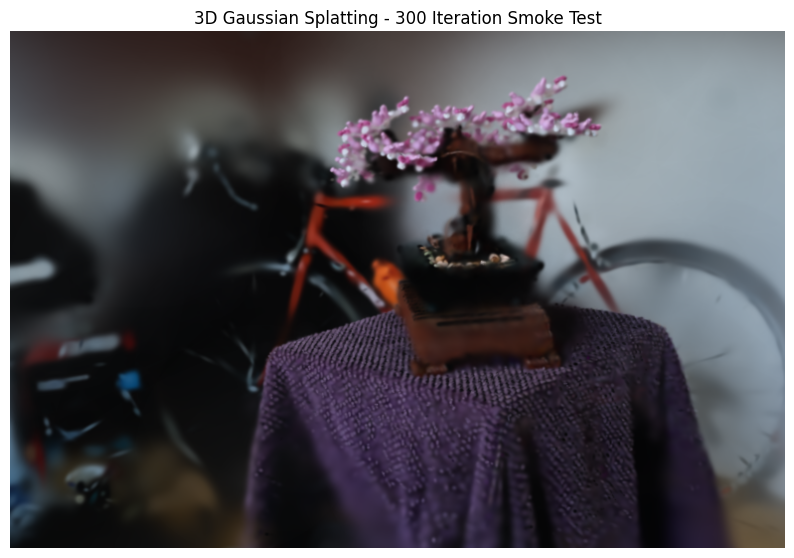

Displayed render: /kaggle/working/outputs/kaggle/bonsai_smoke/renders/00000.png


In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(first_render)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title(
    "3D Gaussian Splatting - "
    "300 Iteration Smoke Test"
)
plt.show()

print(
    "Displayed render:",
    first_render
)

## 7. Write Smoke-Test Summary

In [9]:
# ---------------------------------------------------------
# CELL 8: PHASE 4 FINAL SUMMARY
# ---------------------------------------------------------

def read_ply_vertex_count(path):
    with path.open("rb") as file:
        for raw_line in file:
            line = raw_line.decode(
                "utf-8",
                errors="replace"
            ).strip()

            if line.startswith("element vertex "):
                return int(line.split()[-1])

            if line == "end_header":
                break

    return None


# ---------------------------------------------------------
# CORRECT LOSS PARSING
# Ignore "Depth Loss=0.0000000"
# ---------------------------------------------------------

train_log_text = (
    LOG_DIR / "train.log"
).read_text(
    encoding="utf-8",
    errors="replace"
)

loss_values = [
    float(value)
    for value in re.findall(
        r"(?<!Depth )Loss=([0-9eE+\-.]+)",
        train_log_text
    )
]

finite_losses = [
    value
    for value in loss_values
    if math.isfinite(value)
]

if len(finite_losses) < 2:
    raise SystemExit(
        "Could not find enough valid training loss values."
    )


# ---------------------------------------------------------
# GPU INFORMATION
# ---------------------------------------------------------

gpu_query = subprocess.check_output(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total,driver_version",
        "--format=csv,noheader,nounits",
    ],
    text=True
).strip().splitlines()[0].split(",")

gpu_name, gpu_vram_mb, driver_version = [
    part.strip()
    for part in gpu_query
]


# ---------------------------------------------------------
# CREATE SUMMARY
# ---------------------------------------------------------

summary = {
    "phase": "Phase 4 - 3DGS GPU Smoke Test",

    "status": "SUCCESS",

    "backend": "kaggle",

    "dataset": "Mip-NeRF 360 Bonsai",

    "source_path": str(SOURCE_PATH),

    "training_scene_path": str(SCENE_PATH),

    "image_count": len(images),

    "sparse_model_path": str(copied_sparse_dir),

    "implementation":
        "graphdeco-inria/gaussian-splatting",

    "implementation_repository":
        REPO_URL,

    "implementation_commit":
        commit,

    "implementation_license":
        "Non-commercial research/evaluation license "
        "from Inria and MPII",

    "gpu_model":
        gpu_name,

    "gpu_vram_mb":
        int(gpu_vram_mb),

    "gpu_vram_gb":
        round(int(gpu_vram_mb) / 1024, 2),

    "nvidia_driver":
        driver_version,

    "torch_version":
        torch.__version__,

    "torch_cuda_version":
        torch.version.cuda,

    "iterations":
        ITERATIONS,

    "training_runtime_seconds":
        round(train_seconds, 2),

    "render_runtime_seconds":
        round(render_seconds, 2),

    "initial_loss":
        finite_losses[0],

    "final_loss":
        finite_losses[-1],

    "loss_changed":
        abs(
            finite_losses[-1]
            - finite_losses[0]
        ) > 1e-12,

    "number_of_gaussians":
        read_ply_vertex_count(point_cloud),

    "checkpoint_path":
        str(
            CHECKPOINT_DIR
            / checkpoint.name
        ),

    "point_cloud_path":
        str(point_cloud),

    "render_count":
        len(render_files),

    "render_path":
        str(first_render),

    "logs_dir":
        str(LOG_DIR),

    "warnings": [
        "300 iterations is a smoke test only, "
        "not the final-quality reconstruction."
    ],
}


# ---------------------------------------------------------
# SAVE SUMMARY.JSON
# ---------------------------------------------------------

summary_path = (
    MODEL_PATH
    / "summary.json"
)

summary_path.write_text(
    json.dumps(
        summary,
        indent=2,
        sort_keys=True
    ),
    encoding="utf-8"
)

print(
    json.dumps(
        summary,
        indent=2,
        sort_keys=True
    )
)

print("\nSummary saved at:")
print(summary_path)

print("\nPHASE 4 COMPLETED SUCCESSFULLY ✅")

{
  "backend": "kaggle",
  "checkpoint_path": "/kaggle/working/outputs/kaggle/bonsai_smoke/checkpoints/chkpnt300.pth",
  "dataset": "Mip-NeRF 360 Bonsai",
  "final_loss": 0.1096482,
  "gpu_model": "Tesla T4",
  "gpu_vram_gb": 15.0,
  "gpu_vram_mb": 15360,
  "image_count": 292,
  "implementation": "graphdeco-inria/gaussian-splatting",
  "implementation_commit": "54c035f7834b564019656c3e3fcc3646292f727d",
  "implementation_license": "Non-commercial research/evaluation license from Inria and MPII",
  "implementation_repository": "https://github.com/graphdeco-inria/gaussian-splatting.git",
  "initial_loss": 0.2694682,
  "iterations": 300,
  "logs_dir": "/kaggle/working/outputs/kaggle/bonsai_smoke/logs",
  "loss_changed": true,
  "number_of_gaussians": 100730,
  "nvidia_driver": "580.159.04",
  "phase": "Phase 4 - 3DGS GPU Smoke Test",
  "point_cloud_path": "/kaggle/working/outputs/kaggle/bonsai_smoke/point_cloud/iteration_300/point_cloud.ply",
  "render_count": 292,
  "render_path": "/kagg

In [10]:
# ---------------------------------------------------------
# CELL 9: ARCHIVE PHASE 4 OUTPUTS
# ---------------------------------------------------------

archive_base = Path("/kaggle/working/phase4_bonsai_smoke")

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=MODEL_PATH
)

print("Phase 4 archive created:")
print(archive_path)

archive_size_mb = Path(archive_path).stat().st_size / (1024 ** 2)

print(
    "Archive size:",
    round(archive_size_mb, 2),
    "MB"
)

print("\nPHASE 4 ARTIFACTS READY ✅")

Phase 4 archive created:
/kaggle/working/phase4_bonsai_smoke.zip
Archive size: 306.29 MB

PHASE 4 ARTIFACTS READY ✅
